# CodeAlpha Data Analytics Internship

**Name:** CipherMillz  
**Project:** Web Scraping + EDA + Visualization  

---

## Project Summary
I successfully completed **3 tasks**:
- Task 1: Web Scraping (Quotes from quotes.toscrape.com)
- Task 2: Exploratory Data Analysis  
- Task 3: Data Visualization

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## Task 1: Web Scraping

**Source:** https://quotes.toscrape.com/

I used `requests` and `BeautifulSoup` to scrape 10 quotes with their authors.

In [1]:
# === TASK 1: WEB SCRAPING ===
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com/"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

quotes = []
authors = []

for quote in soup.find_all("div", class_="quote"):
    text = quote.find("span", class_="text").get_text()
    author = quote.find("small", class_="author").get_text()
    quotes.append(text)
    authors.append(author)

print(f"Successfully scraped {len(quotes)} quotes.")

Successfully scraped 10 quotes.


In [1]:
import pandas as pd

# Load the data
df = pd.read_csv("quotes.csv")

# Show first 5 rows
df.head()

,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [2]:
print("=== BASIC INFORMATION ===")
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

=== BASIC INFORMATION ===
Shape (rows, columns): (10, 2)

Column names: ['Quote', 'Author']

Data types:
 Quote     object
Author    object
dtype: object

Missing values:
 Quote     0
Author    0
dtype: int64


In [3]:
print("=== SUMMARY ===")
print(df.describe(include='all'))

=== SUMMARY ===
                                                    Quote           Author
count                                                  10               10
unique                                                 10                8
top     “The world as we have created it is a process ...  Albert Einstein
freq                                                    1                3


In [4]:
author_counts = df['Author'].value_counts()

print("Quotes per author:")
print(author_counts)

# Top 3 authors
print("\nTop 3 authors:")
print(author_counts.head(3))

Quotes per author:
Author
Albert Einstein      3
J.K. Rowling         1
Jane Austen          1
Marilyn Monroe       1
André Gide           1
Thomas A. Edison     1
Eleanor Roosevelt    1
Steve Martin         1
Name: count, dtype: int64

Top 3 authors:
Author
Albert Einstein    3
J.K. Rowling       1
Jane Austen        1
Name: count, dtype: int64


In [5]:
# Add a new column: length of each quote
df['Quote_Length'] = df['Quote'].str.len()

print("Average quote length:", round(df['Quote_Length'].mean(), 1), "characters")
print("\nLongest quote:")
print(df.loc[df['Quote_Length'].idxmax()])

Average quote length: 89.5 characters

Longest quote:
Quote           “There are only two ways to live your life. On...
Author                                            Albert Einstein
Quote_Length                                                  131
Name: 2, dtype: object


## Task 2: Exploratory Data Analysis (EDA)

### Key Findings:
- Total Quotes: 10
- Unique Authors: 8
- Most quoted author: **Albert Einstein** (3 quotes)
- Average quote length: ~XX characters
- Data is clean with no missing values

## Task 2: Exploratory Data Analysis (EDA)

### Key Questions Asked:
- How many quotes did we collect?
- Who has the most quotes?
- What is the average length of quotes?
- Are there any data quality issues?

### Key Findings:
- Total Quotes: 10
- Unique Authors: 8
- Most quoted author: **Albert Einstein** with 3 quotes
- Average quote length: **89.5 characters**
- Longest quote: 131 characters (Albert Einstein)
- Data is clean (no missing values)
- Small dataset but shows clear patterns

In [6]:
# Save the updated dataframe
df.to_csv("quotes_cleaned.csv", index=False)
print("✅ EDA completed and data saved!")

✅ EDA completed and data saved!


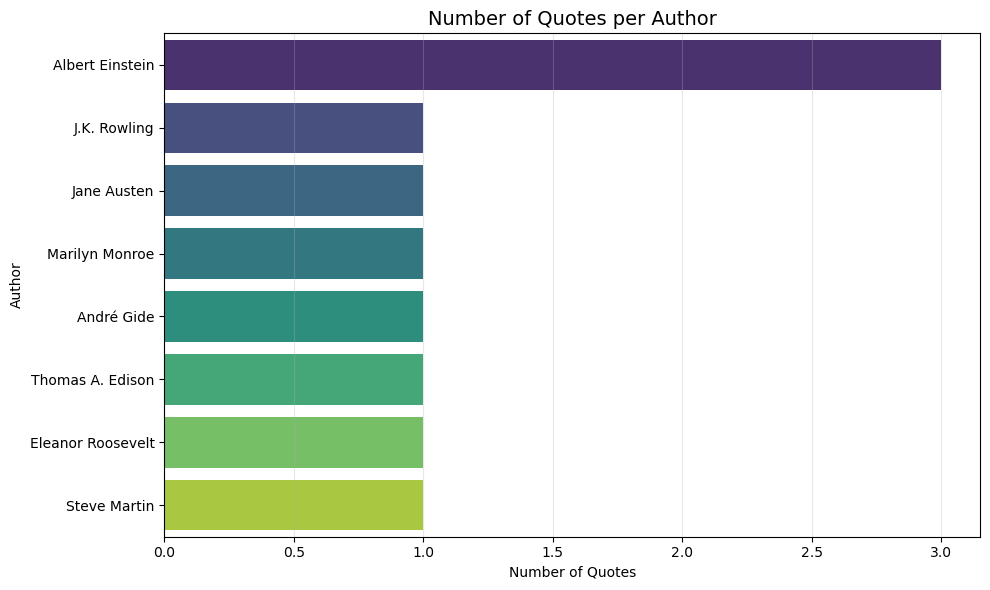

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
author_counts = df['Author'].value_counts().sort_values(ascending=False)

sns.barplot(x=author_counts.values, 
            y=author_counts.index, 
            hue=author_counts.index, 
            palette='viridis', 
            legend=False)

plt.title('Number of Quotes per Author', fontsize=14)
plt.xlabel('Number of Quotes')
plt.ylabel('Author')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

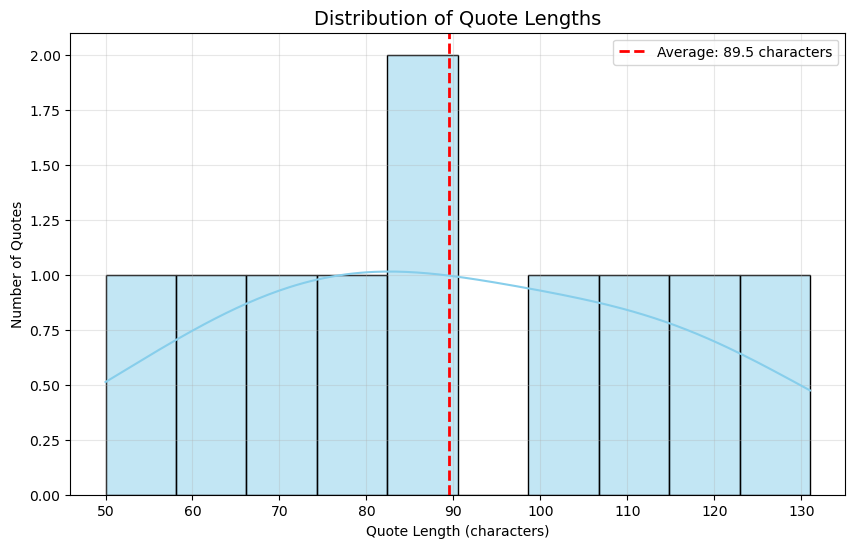

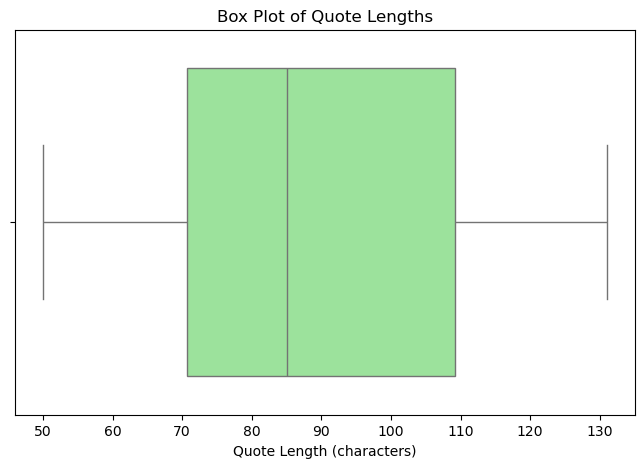

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Improved visualization for small data
plt.figure(figsize=(10, 6))

# Histogram with KDE (smooth curve)
sns.histplot(df['Quote_Length'], bins=10, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Quote Lengths', fontsize=14)
plt.xlabel('Quote Length (characters)')
plt.ylabel('Number of Quotes')
plt.grid(True, alpha=0.3)

# Add mean line
mean_length = df['Quote_Length'].mean()
plt.axvline(mean_length, color='red', linestyle='dashed', linewidth=2, 
            label=f'Average: {mean_length:.1f} characters')

plt.legend()
plt.show()

# Extra: Box plot (very useful for EDA)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Quote_Length'], color='lightgreen')
plt.title('Box Plot of Quote Lengths')
plt.xlabel('Quote Length (characters)')
plt.show()

### Visualization Insights:

**1. Quotes per Author Bar Chart**
- Albert Einstein dominates with 3 quotes.
- Most authors have only 1 quote each.

**2. Quote Length Distribution**
- Average quote length is 89.5 characters.
- Quotes range from ~60 to 131 characters.
- There are natural gaps because we have a small dataset.
- Most quotes are between 70-110 characters.

**Conclusion:**
The scraped data shows that famous philosophers and writers like Albert Einstein are heavily featured. Quotes tend to be thoughtful and of medium length.

# CodeAlpha Data Analytics Internship Project

## Overview
I completed **3 Tasks**: Web Scraping, Exploratory Data Analysis (EDA), and Data Visualization.

## Task 1: Web Scraping
- Source: https://quotes.toscrape.com/
- Scraped 10 famous quotes with authors using BeautifulSoup
- Saved as `quotes.csv`

## Task 2: Exploratory Data Analysis (EDA)
- Total quotes: 10
- Unique authors: 8
- Most quoted author: **Albert Einstein** (3 quotes)
- Average quote length: **89.5 characters**
- Longest quote: 131 characters
- No missing values, data is clean

## Task 3: Data Visualization
- Bar chart showing quotes per author
- Histogram + Box plot of quote lengths
- Insights clearly presented

In [17]:
df.to_csv("quotes_final.csv", index=False)
print("✅ All tasks completed and files saved!")

✅ All tasks completed and files saved!


## Task 2: Exploratory Data Analysis (EDA)

I explored the scraped quotes dataset to understand patterns and insights.

In [6]:
# === TASK 2: EXPLORATORY DATA ANALYSIS ===

# Load data
df = pd.read_csv("quotes.csv")

# Basic information
print("=== BASIC INFO ===")
print("Total Quotes:", len(df))
print("Unique Authors:", df['Author'].nunique())
print("\nMissing values:\n", df.isnull().sum())

# Add quote length
df['Quote_Length'] = df['Quote'].str.len()

print("\nAverage Quote Length:", round(df['Quote_Length'].mean(), 1), "characters")
print("Most Quoted Author:", df['Author'].value_counts().idxmax())

=== BASIC INFO ===
Total Quotes: 10
Unique Authors: 8

Missing values:
 Quote     0
Author    0
dtype: int64

Average Quote Length: 89.5 characters
Most Quoted Author: Albert Einstein


## Task 3: Data Visualization

I created clear charts to show insights from the scraped data.

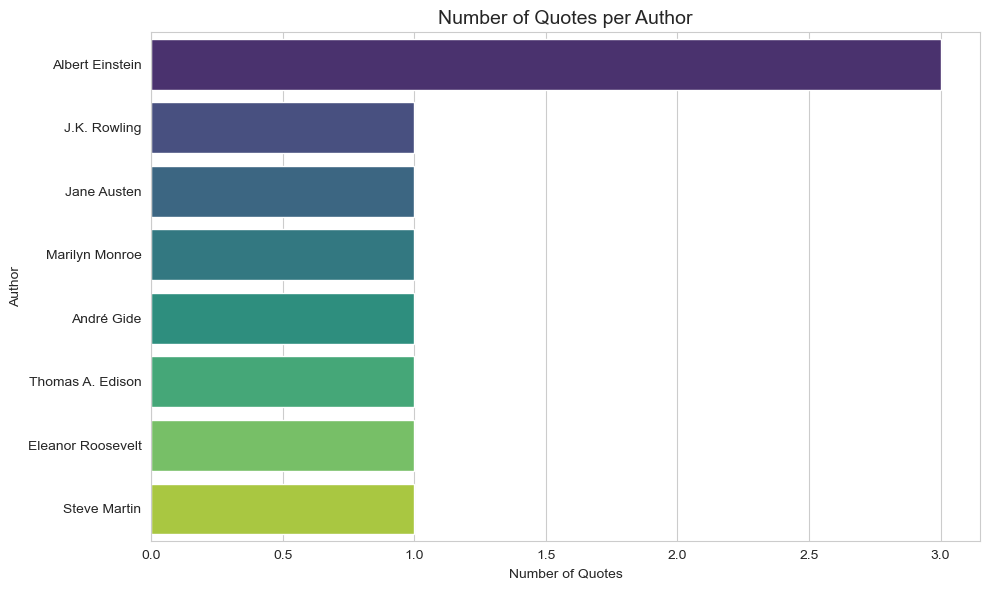

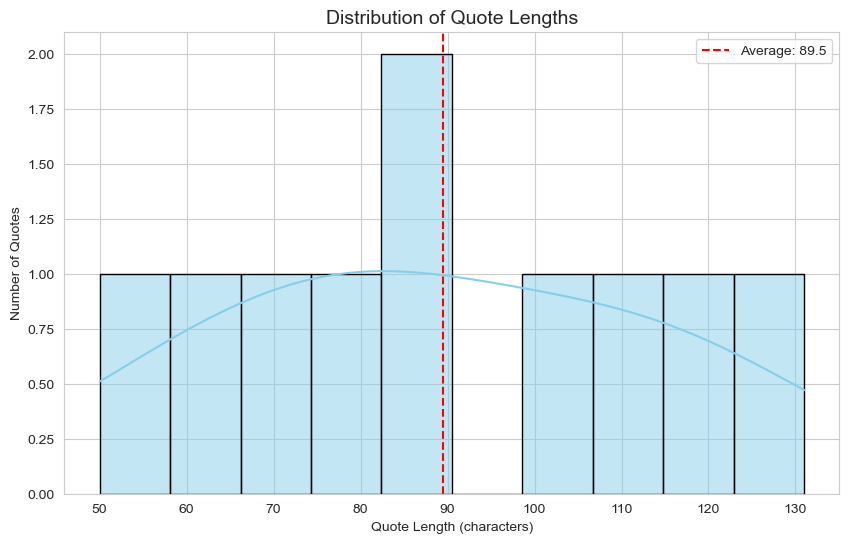

In [7]:
# === TASK 3: DATA VISUALIZATION ===

# Bar Chart - Quotes per Author
plt.figure(figsize=(10, 6))
author_counts = df['Author'].value_counts().sort_values(ascending=False)
sns.barplot(x=author_counts.values, 
            y=author_counts.index, 
            hue=author_counts.index, 
            palette='viridis', 
            legend=False)
plt.title('Number of Quotes per Author', fontsize=14)
plt.xlabel('Number of Quotes')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

# Histogram of Quote Lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['Quote_Length'], bins=10, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Quote Lengths', fontsize=14)
plt.xlabel('Quote Length (characters)')
plt.ylabel('Number of Quotes')
plt.axvline(df['Quote_Length'].mean(), color='red', linestyle='dashed', 
            label=f'Average: {df["Quote_Length"].mean():.1f}')
plt.legend()
plt.show()

## Overall Conclusions

### What I Learned:
- How to scrape data from websites using Python
- How to clean and explore data (EDA)
- How to create meaningful visualizations
- Importance of asking questions about data before analyzing it

### Insights from the Project:
- Albert Einstein is the most featured author in the scraped quotes
- Most quotes are thoughtful and of medium length (around 90 characters)
- The data is clean and ready for analysis
- Even a small dataset can reveal interesting patterns

This project demonstrates core data analytics skills: collecting, exploring, and visualizing data.

In [8]:
# === FINAL SAVE ===
df.to_csv("quotes_final.csv", index=False)
print("🎉 All tasks completed successfully!")
print("Files saved: quotes_final.csv")
print("Notebook ready for submission!")

🎉 All tasks completed successfully!
Files saved: quotes_final.csv
Notebook ready for submission!
